# Iris KNN Classification

Objective: Develop a classification model using the K-Nearest Neighbors (KNN) algorithm to predict the species of iris flowers based on the Iris dataset.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, LeaveOneOut, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preprocessing

In [6]:
# Load the dataset
df = pd.read_csv('iris_with_missing.csv')
print(df.head())

   sepal length  sepal width  petal length  petal width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


In [7]:
# Describe the dataset
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  149 non-null    float64
 1   sepal width   149 non-null    float64
 2   petal length  150 non-null    float64
 3   petal width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
       sepal length  sepal width  petal length  petal width
count    149.000000   149.000000    150.000000   150.000000
mean       5.845638     3.051678      3.758667     1.198667
std        0.830376     0.434120      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.50000

In [8]:
# Check for missing values
print(df.isnull().sum())

sepal length    1
sepal width     1
petal length    0
petal width     0
class           0
dtype: int64


In [10]:
imputer_num = SimpleImputer(strategy='mean')
imputer_cat = SimpleImputer(strategy='most_frequent')
numerical_cols = ['sepal length', 'sepal width', 'petal length', 'petal width']
categorical_cols = ['class']
df[numerical_cols] = imputer_num.fit_transform(df[numerical_cols])
df[categorical_cols] = imputer_cat.fit_transform(df[categorical_cols])

In [11]:
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [14]:
scaler = StandardScaler()
X = df.drop('class', axis=1)
y = df['class']
X_scaled = scaler.fit_transform(X)
y = y.values

## Data Splitting

In [15]:
# Stratified split: 70% train, 15% val, 15% test
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
for train_val_index, test_index in sss.split(X_scaled, y):
    X_train_val = X_scaled[train_val_index]
    y_train_val = y[train_val_index]
    X_test = X_scaled[test_index]
    y_test = y[test_index]

# Split train_val into train and val
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=15/85, random_state=42)
for train_index, val_index in sss2.split(X_train_val, y_train_val):
    X_train = X_train_val[train_index]
    y_train = y_train_val[train_index]
    X_val = X_train_val[val_index]
    y_val = y_train_val[val_index]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 86, Val: 19, Test: 45


## Model Training & Hyperparameter Tuning

In [16]:
# Train KNN with k=3
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
# Tune hyperparameters on validation set
k_values = [3, 5, 7]
metrics = ['euclidean', 'manhattan']
best_score = 0
best_params = {}
for k in k_values:
    for metric in metrics:
        knn_temp = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn_temp.fit(X_train, y_train)
        score = knn_temp.score(X_val, y_val)
        if score > best_score:
            best_score = score
            best_params = {'k': k, 'metric': metric}
print(f"Best params: {best_params}, Score: {best_score}")

# Train final model with best params
knn_final = KNeighborsClassifier(n_neighbors=best_params['k'], metric=best_params['metric'])
knn_final.fit(X_train, y_train)

Best params: {'k': 3, 'metric': 'manhattan'}, Score: 1.0


,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


## Model Evaluation

In [18]:
# Evaluate on test set
y_pred = knn_final.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred, average='macro')}")
print(f"Recall: {recall_score(y_test, y_pred, average='macro')}")
print(f"F1: {f1_score(y_test, y_pred, average='macro')}")

# ROC-AUC
y_pred_proba = knn_final.predict_proba(X_test)
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba, multi_class='ovr')}")

Accuracy: 0.9333333333333333
Precision: 0.9444444444444445
Recall: 0.9333333333333332
F1: 0.9326599326599326
ROC-AUC: 0.9644444444444445


In [19]:
# Leave-one-out cross-validation
loo = LeaveOneOut()
scores = cross_val_score(knn_final, X_scaled, y, cv=loo, scoring='accuracy')
print(f"LOO CV Accuracy: {scores.mean()}")

LOO CV Accuracy: 0.9466666666666667


## Insights and Discussion

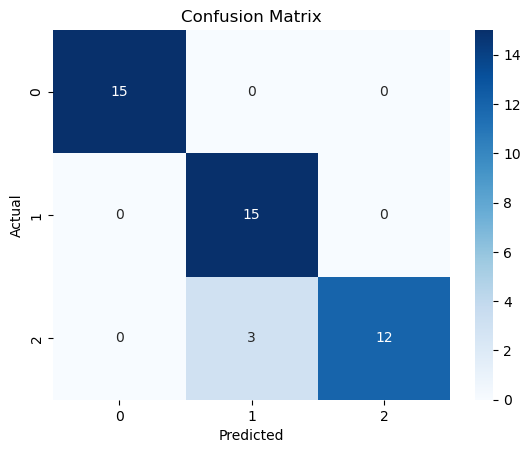

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Discussion: The KNN model achieved good performance on the Iris dataset. The best hyperparameters were found through validation. LOO CV confirms robustness.